# Diagnóstico difuso de hipertensión arterial
En la siguiente infografía se informan criterios para definir la tensión arterial.

Los límites son demasiado estrictos. Intente fuzzificar este concepto con una variable difusa y un árbol básico de proposiciones. 

Defina algunas (o todas) las diferentes clasificaciones. Las proposiciones a evaluar serían "El paciente tiene la presión normal", "El paciente presenta presión elevada", "El paciente es hipertenso grado X", etc.
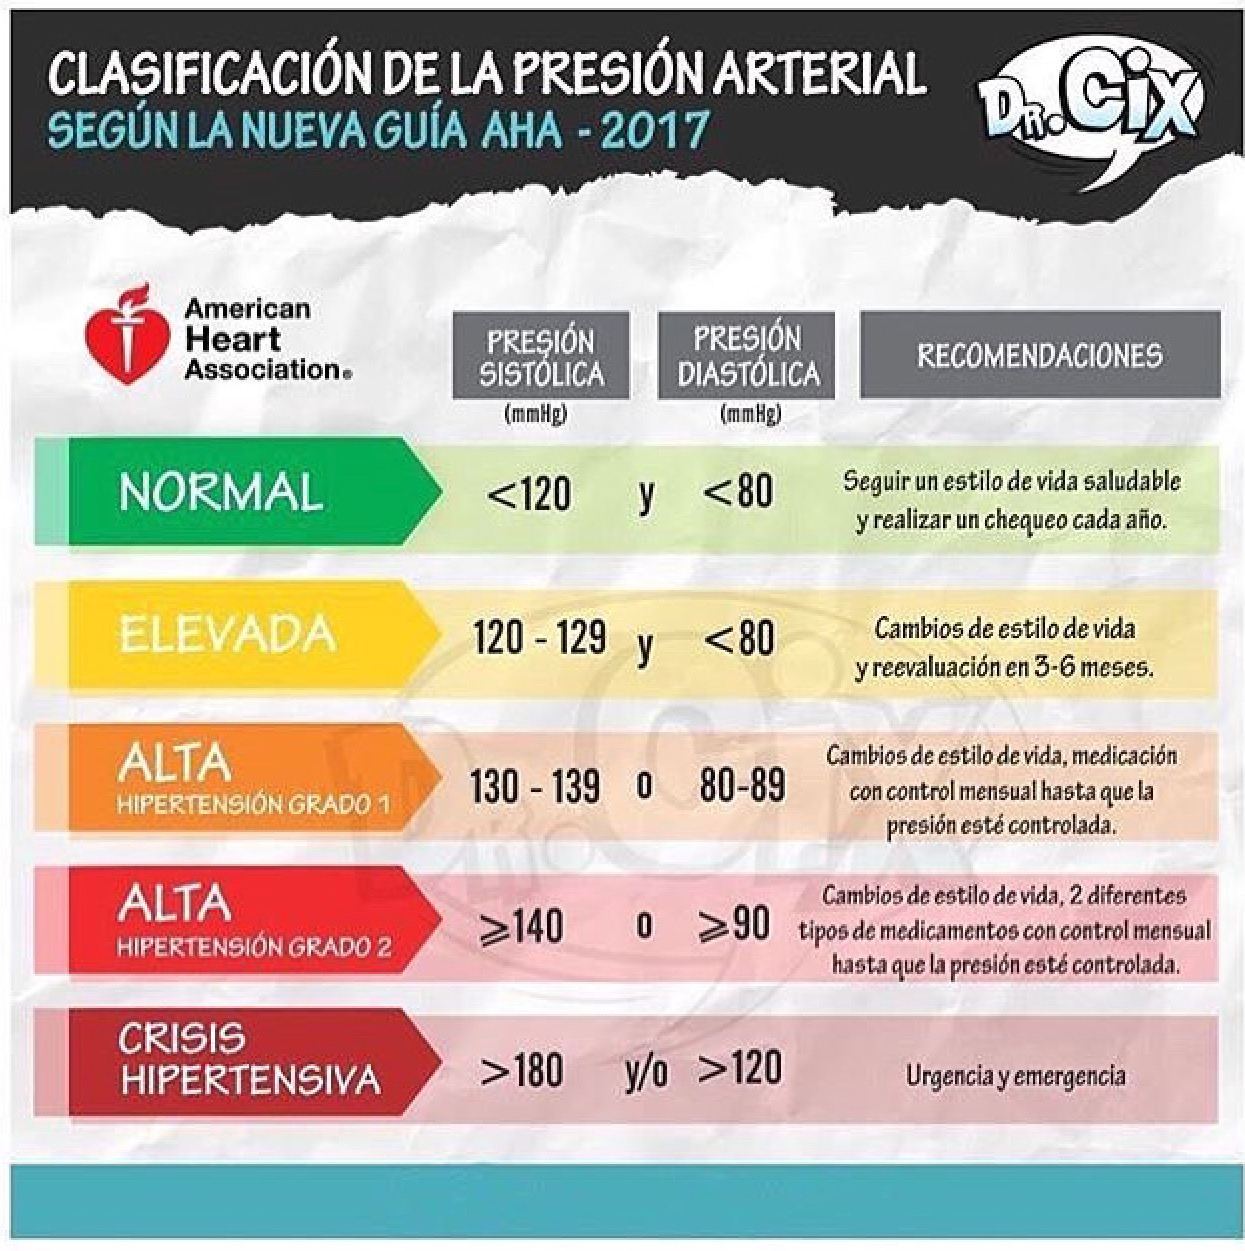

## Variables lingüísticas difusas

| Variable | Término lingüístico | Tipo de función | Parámetros `[a, b, c, d]` |
|---|---|---|---|
| Sistólica ($S$) | Normal ($N_S$) | Trapezoidal (forma Z) | `[80, 80, 115, 125]` |
| Sistólica ($S$) | Elevada ($E_S$) | Triangular / trapezoidal | `[118, 123, 126, 132]` |
| Sistólica ($S$) | Grado 1 ($G1_S$) | Trapezoidal | `[128, 132, 137, 143]` |
| Sistólica ($S$) | Grado 2 ($G2_S$) | Trapezoidal | `[138, 145, 175, 185]` |
| Sistólica ($S$) | Crisis ($C_S$) | Trapezoidal (forma S) | `[175, 185, 220, 220]` |
| Diastólica ($D$) | Normal ($N_D$) | Trapezoidal (forma Z) | `[50, 50, 76, 82]` |
| Diastólica ($D$) | Grado 1 ($G1_D$) | Trapezoidal | `[78, 82, 87, 92]` |
| Diastólica ($D$) | Grado 2 ($G2_D$) | Trapezoidal | `[88, 93, 115, 125]` |
| Diastólica ($D$) | Crisis ($C_D$) | Trapezoidal (forma S) | `[115, 125, 140, 140]` |
Asumimos que 80 <= S <= 220 y que 50 <= D <= 140

## Recomendaciones

| Clasificación | Recomendación |
|---|---|
| Normal | Realizar un estilo de vida saludable y realizar un chequeo cada año. |
| Elevada | Cambios de estilo de vida y reevaluación en 3-6 meses. |
| Alta, nivel 1 | Cambios de estilo de vida, medicación con control mensual hasta que la presión esté controlada. |
| Alta, nivel 2 | Cambios de estilo de vida, 2 diferentes tipos de medicamentos con control mensual hasta que la presión esté controlada. |
| Crisis | Urgencia y emergencia |

## Árboles de proposiciones difusas
Proposición 1: "El paciente presenta presión NORMAL"$$\mathcal{P}_{\text{normal}} \equiv (S \text{ es } N_S) \land (D \text{ es } N_D)$$
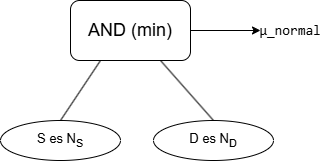

Proposición 2: "El paciente presenta presión ELEVADA" $$\mathcal{P}_{\text{elevada}} \equiv (S \text{ es } E_S) \land (D \text{ es } N_D)$$
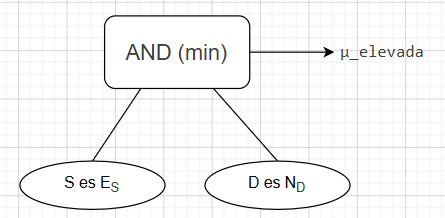

Proposición 3: "El paciente presenta HIPERTENSIÓN GRADO 1"$$\mathcal{P}_{\text{grado1}} \equiv (S \text{ es } G1_S) \lor (D \text{ es } G1_D)$$
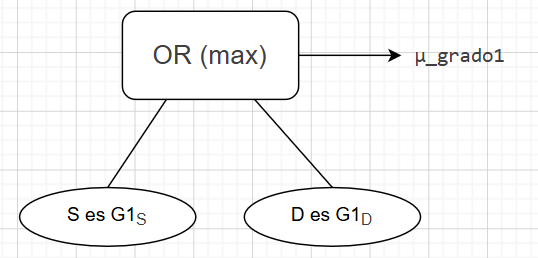

Proposición 4: "El paciente presenta HIPERTENSIÓN GRADO 2" $$\mathcal{P}_{\text{grado2}} \equiv (S \text{ es } G2_S) \lor (D \text{ es } G2_D)$$
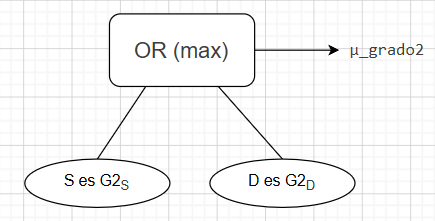

Proposición 5: "El paciente tiene una crisis hipertensiva" $$\mathcal{P}_{\text{crisis}} \equiv (S \text{ es } C_S) \lor (D \text{ es } C_D)$$
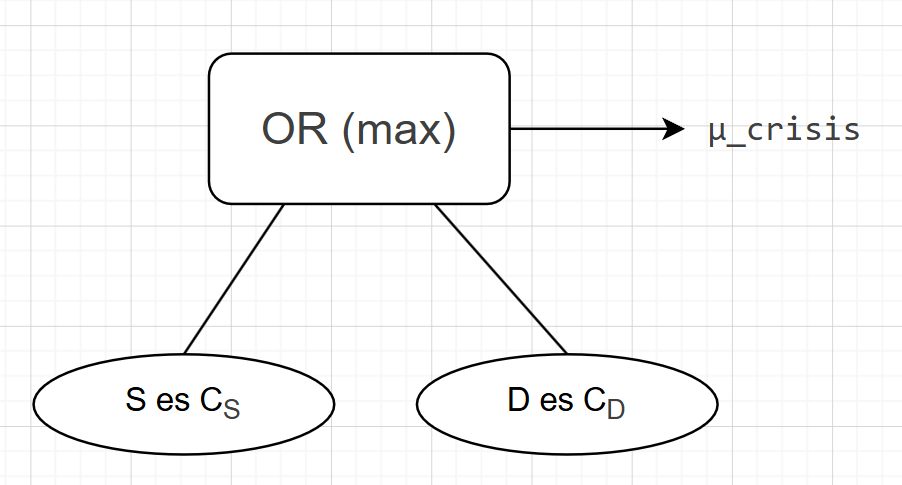

In [6]:
import numpy as np


sigma_s = (220 - 80)/np.sqrt(8)
sigma_d = (140 - 50)/np.sqrt(8)

def gaussiana(x_val: float, c: float, sig: float) -> float:
    """
    **Funcion de pertenencia gaussiana.**
    
    ## Parametros:
    - x_val: valor escalar o array de numpy con las entradas x.
    - c: centroide de la campana (escalar).
    - sig: ancho / desviacion estandar sigma (escalar).

    ## Retorna:
      Grado de pertenencia mu en el intervalo (0, 1].
    """
    return np.exp(-(x_val-c)**2/(2*sig**2))

def presion_normal(presion_sistolica: int, presion_diastolica: int) -> float:
    """Devuelve un número entre 0 y 1 que representa el grado de pertenencia a la categoría de presión normal.
    
    ## Parametros:
    - presion_sistolica: valor de la presión sistólica.
    - presion_diastolica: valor de la presión diastólica.

    ## Retorna:
    - Grado de pertenencia a la categoría de presión normal.
    """
    media_normal_s = 120
    media_normal_d = 80
    return min(gaussiana(presion_sistolica, media_normal_s, sigma_s),
               gaussiana(presion_diastolica, media_normal_d, sigma_d))

def presion_elevada(presion_sistolica: int, presion_diastolica: int) -> float:
    """Devuelve un número entre 0 y 1 que representa el grado de pertenencia a la categoría de presión elevada.
    
    ## Parametros:
    - presion_sistolica: valor de la presión sistólica.
    - presion_diastolica: valor de la presión diastólica.

    ## Retorna:
    - Grado de pertenencia a la categoría de presión elevada.
    """
    media_elevada_s = (120+130)/2
    media_normal_d = 80
    return min(gaussiana(presion_sistolica, media_elevada_s, sigma_s),
               gaussiana(presion_diastolica, media_normal_d, sigma_d))

def presion_alta_grado1(presion_sistolica: int, presion_diastolica: int) -> float:
    """Devuelve un número entre 0 y 1 que representa el grado de pertenencia a la categoría de presión alta grado 1.
    
    ## Parametros:
    - presion_sistolica: valor de la presión sistólica.
    - presion_diastolica: valor de la presión diastólica.

    ## Retorna:
    - Grado de pertenencia a la categoría de presión alta grado 1.
    """
    media_alta_lvl1_s = (130+140)/2
    media_alta_lvl1_d = (80+90)/2
    return max(gaussiana(presion_sistolica, media_alta_lvl1_s, sigma_s),
               gaussiana(presion_diastolica, media_alta_lvl1_d, sigma_d))

def presion_alta_grado2(presion_sistolica: int, presion_diastolica: int) -> float:
    """Devuelve un número entre 0 y 1 que representa el grado de pertenencia a la categoría de presión alta grado 2.
    
    ## Parametros:
    - presion_sistolica: valor de la presión sistólica.
    - presion_diastolica: valor de la presión diastólica.

    ## Retorna:
    - Grado de pertenencia a la categoría de presión alta grado 2.
    """
    media_alta_lvl2_s = (140+180)/2
    media_alta_lvl2_d = (90+120)/2
    return max(gaussiana(presion_sistolica, media_alta_lvl2_s, sigma_s),
               gaussiana(presion_diastolica, media_alta_lvl2_d, sigma_d))

def crisis_hipertensiva(presion_sistolica: int, presion_diastolica: int) -> float:
    """Devuelve un número entre 0 y 1 que representa el grado de pertenencia a la categoría de crisis hipertensiva.
    
    ## Parametros:
    - presion_sistolica: valor de la presión sistólica.
    - presion_diastolica: valor de la presión diastólica.

    ## Retorna:
    - Grado de pertenencia a la categoría de crisis hipertensiva.
    """
    media_crisis_s = 180
    media_crisis_d = 120
    return max(gaussiana(presion_sistolica, media_crisis_s, sigma_s),
               gaussiana(presion_diastolica, media_crisis_d, sigma_d))




In [15]:
PRESION_NORMAL = "Presion normal", "Realizar un estilo de vida saludable y realizar un chequeo cada año."
PRESION_ELEVADA = "Presion elevada", "Cambios de estilo de vida y reevaluación en 3-6 meses."
PRESION_ALTA_LVL1 = "Presion alta. Hipertensión grado 1", "Cambios de estilo de vida, medicación con control mensual hasta que la presión esté controlada."
PRESION_ALTA_LVL2 = "Presion alta. Hipertensión grado 2", "Cambios de estilo de vida, 2 diferentes tipos de medicamentos con control mensual hasta que la presión esté controlada."
PRESION_CRISIS = "Crisis hipertensiva", "Urgencia y emergencia"

def diagnostico(presion_sistolica: int, presion_diastolica: int) -> tuple[str, str]:
    """Devuelve un string con el diagnóstico difuso de hipertensión arterial.
    
    ## Parametros:
    - presion_sistolica: valor de la presión sistólica.
    - presion_diastolica: valor de la presión diastólica.

    ## Retorna:
    - Diagnóstico y recomendaciones.
    """
    grado_normal = presion_normal(presion_sistolica, presion_diastolica)
    grado_elevada = presion_elevada(presion_sistolica, presion_diastolica)
    grado_alta_lvl1 = presion_alta_grado1(presion_sistolica, presion_diastolica)
    grado_alta_lvl2 = presion_alta_grado2(presion_sistolica, presion_diastolica)
    grado_crisis = crisis_hipertensiva(presion_sistolica, presion_diastolica)

    grados = [grado_normal, grado_elevada, grado_alta_lvl1, grado_alta_lvl2, grado_crisis]
    categorias: list[tuple[str, str]] = [PRESION_NORMAL, PRESION_ELEVADA, PRESION_ALTA_LVL1, PRESION_ALTA_LVL2, PRESION_CRISIS]

    max_grado = max(grados)
    max_index = grados.index(max_grado)

    return categorias[max_index]

In [16]:
import unittest

class TestDiagnostico(unittest.TestCase):

    def test_grados_de_pertenencia_estan_en_rango(self):
        presiones = [
            (120, 80), # La presión debería ser normal
            (125, 80), # Presión elevada
            (135, 85), # Presión alta grado 1
            (160, 105), # Presión alta grado 2
            (220, 140), # Crisis hipertensiva
        ]

        funciones = [
            presion_normal,
            presion_elevada,
            presion_alta_grado1,
            presion_alta_grado2,
            crisis_hipertensiva,
        ]

        for sistolica, diastolica in presiones:
            for funcion in funciones:
                with self.subTest(funcion=funcion.__name__):
                    grado = funcion(sistolica, diastolica)
                    self.assertGreaterEqual(grado, 0)
                    self.assertLessEqual(grado, 1)

    def test_diagnosticos_representativos(self):
        casos: list[tuple[tuple[int, int], tuple[str, str]]] = [
            ((120, 80), PRESION_NORMAL),
            ((125, 80), PRESION_ELEVADA),
            ((135, 90), PRESION_ALTA_LVL1),
            ((160, 105), PRESION_ALTA_LVL2),
            ((220, 140), PRESION_CRISIS),
        ]

        for presiones, esperado in casos:
            with self.subTest(presiones=presiones):
                self.assertEqual(diagnostico(*presiones), esperado)

    def test_diagnostico_devuelve_tupla_valida(self):
        resultado = diagnostico(120, 80)

        self.assertIsInstance(resultado, tuple)
        self.assertEqual(len(resultado), 2)
        self.assertIsInstance(resultado[0], str)
        self.assertIsInstance(resultado[1], str)
        self.assertEqual(resultado[0], PRESION_NORMAL[0])
        self.assertEqual(resultado[1], PRESION_NORMAL[1])

    def test_diagnostico_pertenece_a_una_categoria_valida(self):
        categorias: set[tuple[str, str]] = {
            PRESION_NORMAL,
            PRESION_ELEVADA,
            PRESION_ALTA_LVL1,
            PRESION_ALTA_LVL2,
            PRESION_CRISIS,
        }

        resultado = diagnostico(145, 95)
        self.assertIn(resultado, categorias)


suite = unittest.defaultTestLoader.loadTestsFromTestCase(TestDiagnostico)
unittest.TextTestRunner(verbosity=2).run(suite)
print("No se encontraron errores en las pruebas unitarias.")

test_diagnostico_devuelve_tupla_valida (__main__.TestDiagnostico.test_diagnostico_devuelve_tupla_valida) ... ok
test_diagnostico_pertenece_a_una_categoria_valida (__main__.TestDiagnostico.test_diagnostico_pertenece_a_una_categoria_valida) ... ok
test_diagnosticos_representativos (__main__.TestDiagnostico.test_diagnosticos_representativos) ... ok
test_grados_de_pertenencia_estan_en_rango (__main__.TestDiagnostico.test_grados_de_pertenencia_estan_en_rango) ... ok

----------------------------------------------------------------------
Ran 4 tests in 0.005s

OK


No se encontraron errores en las pruebas unitarias.


In [14]:
presion_sistolica = int(input("Ingrese la presión sistólica: "))
presion_diastolica = int(input("Ingrese la presión diastólica: "))

diagnostico_resultado = diagnostico(presion_sistolica, presion_diastolica)
print(f"Diagnóstico: {diagnostico_resultado[0]}")
print(f"Recomendaciones: {diagnostico_resultado[1]}")

Diagnóstico: Presion alta. Hipertensión grado 1
Recomendaciones: Cambios de estilo de vida, medicación con control mensual hasta que la presión esté controlada.
